In [ ]:
!pip install sklearn scipy matplotlib

# Clustering algorithms

Todays homework consists of two tasks. You are required to implement k-means algorithm and hierarchical clusterization.

### 1. K-Means (1 point)

Implement PNG-image compression algorithm using pixels clustering.

Overall pipeline:

* Using Lloyd's algorithm create **K** _base colors_ based on the given image. _Base color_ is the centroid in the RGB space.

* Convert original image into new one, where each pixel is changed to its closest _base color_.

It is required that the transformed image will be visually similar to the original one.

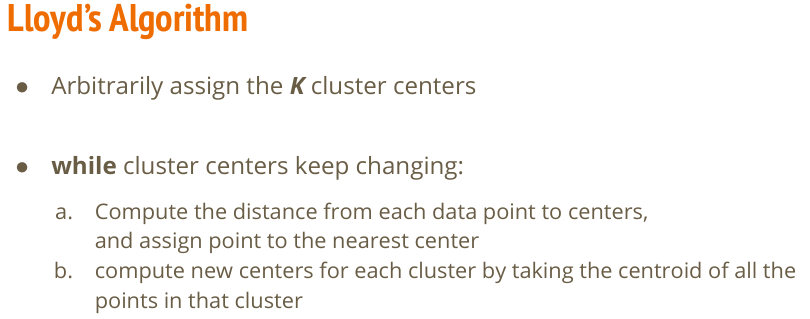

Algorithm minimizes the **loss function**

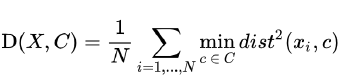


It utilizes Euclidean distance between data points

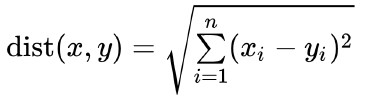

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


To check the convergence criterion, you can use the function `np.allclose(x, y)`

In [ ]:
np.allclose([[1,2,3], [1,2,3]], [[1,2,3], [1,2,2.95]], atol=0.01)

False

In [ ]:
np.allclose([[1,2,3], [1,2,3]], [[1,2,3], [1,2,2.95]], atol=0.1)

True

#### Data download

In [ ]:
# Load the image
img = plt.imread("flower.png")[:,:,:3]

# now img variable contains 3-dimensional array of integers
print(img.shape)

(427, 640, 3)


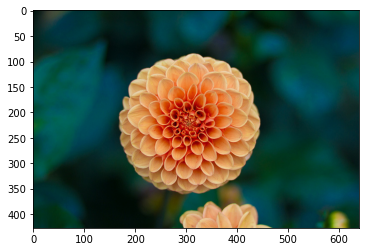

In [ ]:
_ = plt.imshow(img)

In [ ]:
# Each point's color is encoded via 3-dimensional vector in RGB space. This is our features.
print(img[400, 500])

[0.04313726 0.12156863 0.11372549]


In [ ]:
# Transform array into 2 dimension. First corresponds to the data position in picture, second one – to the feature vector.
X = img.reshape((-1,3))
print(X.shape)

(273280, 3)


#### Clustering

Draft class structure. You can change it to your needs

In [ ]:
from scipy.spatial import distance

class KMeans(object):
    def __init__(self, n_clusters, max_iter, seed=0, tol=0.001):
        # number of clusters
        self.n_clusters = n_clusters
        # maximal number of iterations (in case of long convergence)
        self.max_iter = max_iter
        # array-like of shape (n_clusters, n_features) – centroid coordinates
        self.centroids = None
        # array with function losses for each iteration
        self.losses = []
        # random seed
        self.seed = seed
        # tolerance for centroid positions changes
        self.tol = tol

    def distances(self, X):
        '''
        Returns distance from each sample to all centroids
        :param X: array-like of shape (n_samples, n_features)
            Training instances to cluster
        :return dist: array-like of shape (n_samples, n_clusters)
            Matrix of distances
        '''
        # ====================
        # =====   TODO   =====
        # ====================
        # your code goes here

        dist = 0
        return dist

    def loss(self, dist):
        '''
        :param dist: array-like of shape (n_samples, n_clusters)
            Matrix of distances
        :return loss: float
            Value of the loss function
        '''
        # ====================
        # =====   TODO   =====
        # ====================
        # your code goes here
        loss = 0
        return loss

    def initialize(self, X):
        '''
        Initialize centroids
        :param X: array-like of shape (n_samples, n_features)
            Training instances to cluster

        '''
        # ====================
        # =====   TODO   =====
        # ====================
        # your code goes here
        self.centroids = None


    def fit_predict(self, X):
        '''
        Implements Lloyd's algorithm
        :param X: array-like of shape (n_samples, n_features)
            Training instances to cluster
        :return labels : ndarray of shape (n_samples,)
            Index of the cluster each sample belongs to.
        '''
        # initialize random generator
        np.random.seed(self.seed)

        # initialize centroids
        self.initialize(X)

        # ====================
        # =====   TODO   =====
        # ====================
        # your code goes here
        labels = []
        return labels

Run clusterization on our data

In [ ]:
cls = KMeans(n_clusters=8, max_iter=100, seed=0)
y_pred = cls.fit_predict(X)
losses = cls.losses
centroids = cls.centroids

Let's see how loss function decreasing

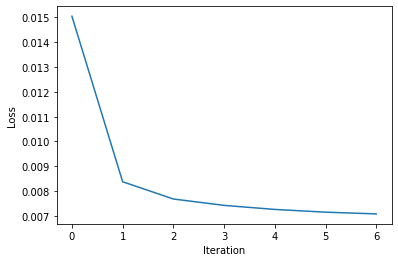

In [ ]:
_ = plt.plot(losses)
_ = plt.xlabel('Iteration')
_ = plt.ylabel('Loss')

Centroids are colors in RGB space. We can draw them

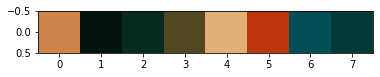

In [ ]:
_ = plt.imshow([centroids])

Now transform `X` matrix into `Y`, where each data points are transformed into centroid points.

In [ ]:
Y = # your code goes here

Let's visualize the result

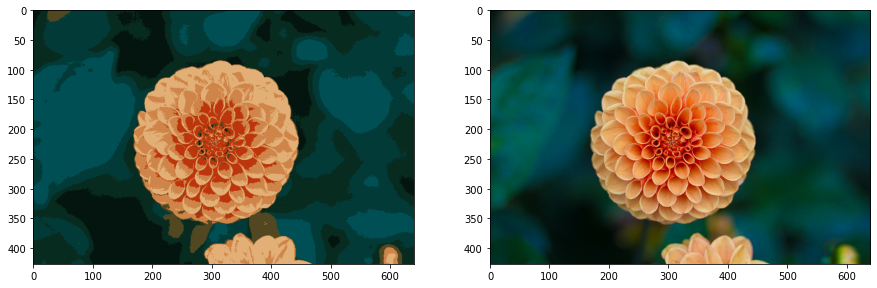

In [ ]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,15))
_ = ax1.imshow(np.array(Y).reshape(img.shape))
_ = ax2.imshow(img)

Experiment with different numbers of clusters

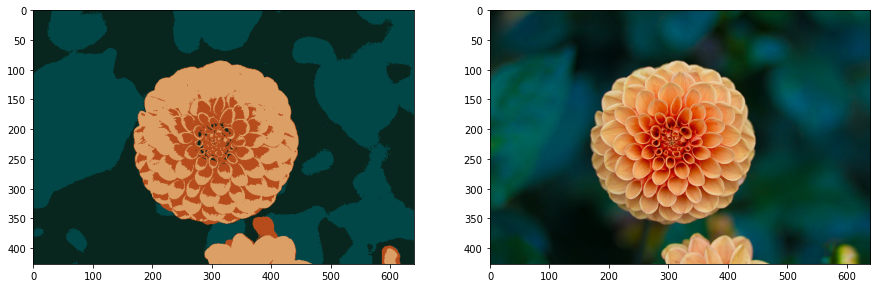

In [ ]:
cls = KMeans(n_clusters=4, max_iter=100, seed=0)
y_pred = cls.fit_predict(X)
losses = cls.losses
centroids = cls.centroids

Y = centroids[y_pred, :]

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,15))
_ = ax1.imshow(np.array(Y).reshape(img.shape))
_ = ax2.imshow(img)

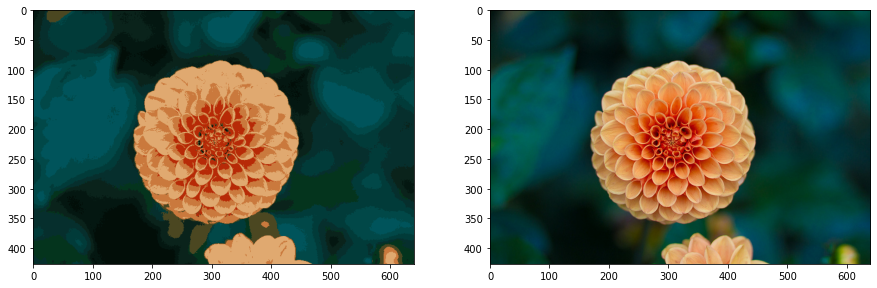

In [ ]:
cls = KMeans(n_clusters=12, max_iter=100, seed=0)
y_pred = cls.fit_predict(X)
losses = cls.losses
centroids = cls.centroids

Y = centroids[y_pred, :]

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,15))
_ = ax1.imshow(np.array(Y).reshape(img.shape))
_ = ax2.imshow(img)

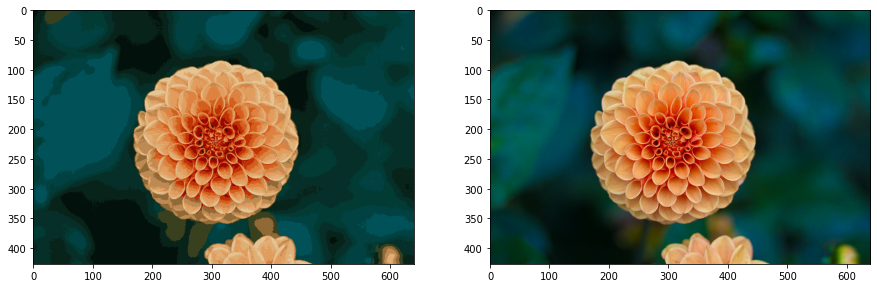

In [ ]:
cls = KMeans(n_clusters=16, max_iter=100, seed=0)
y_pred = cls.fit_predict(X)
losses = cls.losses
centroids = cls.centroids

Y = centroids[y_pred, :]

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,15))
_ = ax1.imshow(np.array(Y).reshape(img.shape))
_ = ax2.imshow(img)

### 2. Hierarchical clustering (1 point)

Implement hierarchical clustering algorithm

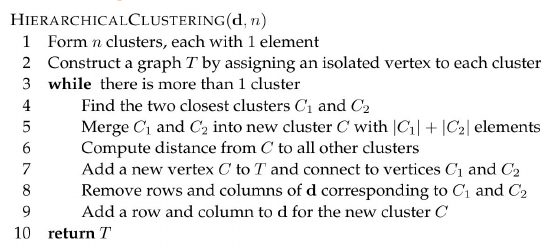



To calculate distances between clusters, use the average distance formuls between the points in cluster:

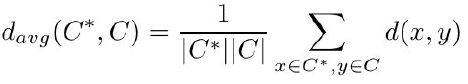

#### 2.1. Implement function `distance_matrix`, calculating pairwise distance matrix between data points.

We will use Euclidean distance metric.


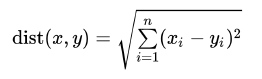


In [ ]:
def distance_matrix(X):
    '''
    Compute matrix of pair-wise distances between samples
    :param X: array-like of shape (n_samples, n_features)
        Samples
    :return D: array-like of shape (n_samples, n_samples)
        Matrix of pair-wise distances between samples
    '''

    # ====================
    # =====   TODO   =====
    # ====================
    D = # your code goes here

    return D

#### 2.2. Implement `linkage` function.

Input is distance matrix.

Output is clusterization result in form of links matrix. Rows correspond to the operation of cluster joining. Each row has the format:


```[C1, C2, dist(C1, C2), N]```

where `C1` и `C2` – joining clusters, `dist(C1, C2)` – distance between joining clusters, `N` – number of points in new cluster

Example:

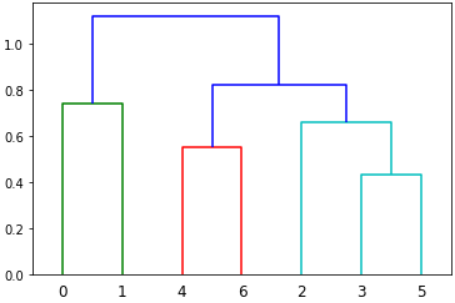

corresponds to
```
Z = [[ 3.    5.    0.43  2.  ]
     [ 4.    6.    0.55  2.  ]
     [ 2.    7.    0.66  3.  ]
     [ 0.    1.    0.74  2.  ]
     [ 8.    9.    0.82  5.  ]
     [10.   11.    1.12  7.  ]]
```


In [ ]:
def linkage(D):
    '''
    :param D: array-like of shape (n_samples, n_samples)
            Matrix of pair-wise distances between samples
    :return linkage: Linkage matrix
    '''
    D1 = D.copy()
    linkage = []
    clusters = []

    # ====================
    # =====   TODO   =====
    # ====================
    # your code goes here

    return linkage


####  Check 1

In [ ]:
# We are given input matrix
D = np.array([[0.  , 0.74, 0.85, 0.54, 0.83, 0.92, 0.89],
              [0.74, 0.  , 1.59, 1.35, 1.2 , 1.48, 1.55],
              [0.85, 1.59, 0.  , 0.63, 1.13, 0.69, 0.73],
              [0.54, 1.35, 0.63, 0.  , 0.66, 0.43, 0.88],
              [0.83, 1.2 , 1.13, 0.66, 0.  , 0.72, 0.55],
              [0.92, 1.48, 0.69, 0.43, 0.72, 0.  , 0.8 ],
              [0.89, 1.55, 0.73, 0.88, 0.55, 0.8 , 0.  ]])

# cluster
Z = linkage(D)

# and print the result
print(np.array(Z))

[[ 3.    5.    0.43  2.  ]
 [ 4.    6.    0.55  2.  ]
 [ 2.    7.    0.66  3.  ]
 [ 0.    1.    0.74  2.  ]
 [ 8.    9.    0.82  5.  ]
 [10.   11.    1.12  7.  ]]


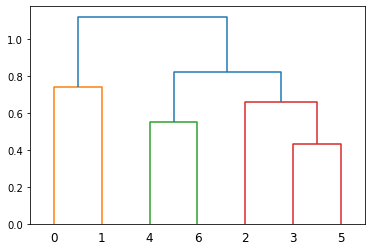

In [ ]:
# use scipy library to visualize dendrogram
from scipy.cluster.hierarchy import dendrogram

# image should be similar to the ones in the beginning of the chapter
_ = dendrogram(Z)

####  Check 2

In [ ]:
D = np.array([
    [0.  , 0.43, 0.93, 0.85, 0.94, 0.7 , 0.95, 0.79, 0.89, 1.34, 0.8 , 0.64, 1.42, 1.37, 0.86, 1.2 , 0.49, 0.19, 1.48, 0.86],
    [0.43, 0.  , 0.66, 0.7 , 1.48, 0.58, 0.7 , 0.55, 0.68, 1.45, 1.31, 0.37, 1.24, 1.69, 0.91, 1.28, 1.04, 0.29, 0.94, 1.05],
    [0.93, 0.66, 0.  , 1.01, 1.42, 0.8 , 0.76, 1.18, 0.21, 1.18, 1.35, 0.82, 0.68, 0.85, 0.75, 1.01, 0.93, 1.03, 0.6 , 0.91],
    [0.85, 0.7 , 1.01, 0.  , 1.02, 0.22, 0.89, 0.91, 0.79, 1.47, 1.04, 1.51, 0.71, 1.63, 0.34, 1.05, 1.24, 0.56, 1.09, 1.25],
    [0.94, 1.48, 1.42, 1.02, 0.  , 1.46, 1.48, 0.95, 1.44, 1.08, 0.3 , 1.29, 1.28, 0.65, 1.  , 0.8 , 0.8 , 0.92, 1.48, 0.65],
    [0.7 , 0.58, 0.8 , 0.22, 1.46, 0.  , 0.77, 1.  , 0.65, 1.25, 1.27, 1.36, 0.81, 1.56, 0.37, 0.98, 1.17, 0.68, 0.88, 1.23],
    [0.95, 0.7 , 0.76, 0.89, 1.48, 0.77, 0.  , 1.41, 1.08, 1.61, 1.65, 0.89, 0.76, 1.32, 0.64, 0.7 , 0.59, 1.07, 0.49, 0.91],
    [0.79, 0.55, 1.18, 0.91, 0.95, 1.  , 1.41, 0.  , 1.05, 0.73, 1.08, 0.7 , 1.49, 1.17, 1.  , 1.34, 1.45, 0.49, 1.06, 1.3 ],
    [0.89, 0.68, 0.21, 0.79, 1.44, 0.65, 1.08, 1.05, 0.  , 0.96, 1.09, 0.94, 0.44, 1.06, 0.9 , 1.47, 1.2 , 0.79, 1.04, 1.39],
    [1.34, 1.45, 1.18, 1.47, 1.08, 1.25, 1.61, 0.73, 0.96, 0.  , 0.96, 1.1 , 1.05, 0.48, 1.36, 1.26, 1.38, 1.38, 1.03, 1.38],
    [0.8 , 1.31, 1.35, 1.04, 0.3 , 1.27, 1.65, 1.08, 1.09, 0.96, 0.  , 1.08, 1.09, 0.79, 1.4 , 1.03, 1.02, 0.78, 1.79, 0.86],
    [0.64, 0.37, 0.82, 1.51, 1.29, 1.36, 0.89, 0.7 , 0.94, 1.1 , 1.08, 0.  , 1.42, 1.2 , 1.61, 1.3 , 0.86, 0.68, 1.04, 0.83],
    [1.42, 1.24, 0.68, 0.71, 1.28, 0.81, 0.76, 1.49, 0.44, 1.05, 1.09, 1.42, 0.  , 0.99, 0.84, 1.2 , 1.21, 1.22, 0.97, 1.58],
    [1.37, 1.69, 0.85, 1.63, 0.65, 1.56, 1.32, 1.17, 1.06, 0.48, 0.79, 1.2 , 0.99, 0.  , 1.13, 0.61, 1.  , 1.6 , 0.81, 0.83],
    [0.86, 0.91, 0.75, 0.34, 1.  , 0.37, 0.64, 1.  , 0.9 , 1.36, 1.4 , 1.61, 0.84, 1.13, 0.  , 0.68, 0.89, 0.86, 0.65, 1.04],
    [1.2 , 1.28, 1.01, 1.05, 0.8 , 0.98, 0.7 , 1.34, 1.47, 1.26, 1.03, 1.3 , 1.2 , 0.61, 0.68, 0.  , 0.92, 1.47, 0.47, 0.42],
    [0.49, 1.04, 0.93, 1.24, 0.8 , 1.17, 0.59, 1.45, 1.2 , 1.38, 1.02, 0.86, 1.21, 1.  , 0.89, 0.92, 0.  , 0.9 , 1.18, 0.49],
    [0.19, 0.29, 1.03, 0.56, 0.92, 0.68, 1.07, 0.49, 0.79, 1.38, 0.78, 0.68, 1.22, 1.6 , 0.86, 1.47, 0.9 , 0.  , 1.56, 1.21],
    [1.48, 0.94, 0.6 , 1.09, 1.48, 0.88, 0.49, 1.06, 1.04, 1.03, 1.79, 1.04, 0.97, 0.81, 0.65, 0.47, 1.18, 1.56, 0.  , 0.84],
    [0.86, 1.05, 0.91, 1.25, 0.65, 1.23, 0.91, 1.3 , 1.39, 1.38, 0.86, 0.83, 1.58, 0.83, 1.04, 0.42, 0.49, 1.21, 0.84, 0.  ]])

Output Linkage matrix and build dendrogram

[[ 0.         17.          0.19        2.        ]
 [ 2.          8.          0.21        2.        ]
 [ 3.          5.          0.22        2.        ]
 [ 4.         10.          0.3         2.        ]
 [14.         22.          0.355       3.        ]
 [ 1.         20.          0.36        3.        ]
 [15.         19.          0.42        2.        ]
 [ 9.         13.          0.48        2.        ]
 [ 6.         18.          0.49        2.        ]
 [12.         21.          0.56        3.        ]
 [11.         25.          0.56333333  4.        ]
 [ 7.         30.          0.6325      5.        ]
 [16.         26.          0.705       3.        ]
 [28.         32.          0.78166667  5.        ]
 [24.         29.          0.80666667  6.        ]
 [23.         27.          0.87        4.        ]
 [31.         34.          0.995      11.        ]
 [33.         36.          1.05890909 16.        ]
 [35.         37.          1.184375   20.        ]]


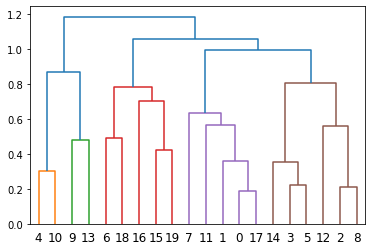

In [ ]:
# ====================
# =====   TODO   =====
# ====================
# your code here


#### 2.3. Digits dataset

In [ ]:
from sklearn import datasets

# Load Digits dataset. It contains images with handwritten digits
digits = datasets.load_digits().images

In [ ]:
# let's choose 20 random items
digits = np.random.permutation(digits)[:20]

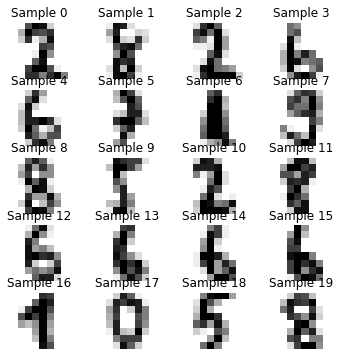

In [ ]:
# and draw them
_, axes = plt.subplots(nrows=5, ncols=4, figsize=(6, 6))
for i, (ax, image) in enumerate(zip(axes.flatten(), digits)):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f'Sample {i}')

In [ ]:
# each image is (8, 8) matrix. Let's make one-dimensional feature vector
XX = digits.reshape((digits.shape[0], -1))

**Cluster vectors and build dendrogram. What conclusions can be drawn from it?**

[[13.         15.         19.97498436  2.        ]
 [ 3.          4.         21.88606863  2.        ]
 [14.         20.         22.53021117  3.        ]
 [ 2.         10.         24.49489743  2.        ]
 [12.         21.         29.72372666  3.        ]
 [ 8.         19.         35.44009029  2.        ]
 [22.         24.         36.02403616  6.        ]
 [ 1.         11.         38.57460304  2.        ]
 [ 0.         23.         38.73449793  3.        ]
 [ 9.         18.         38.83297568  2.        ]
 [ 7.         17.         39.11521443  2.        ]
 [ 6.         16.         40.32369031  2.        ]
 [25.         27.         41.29944172  4.        ]
 [ 5.         31.         44.59701266  3.        ]
 [28.         32.         45.11057415  7.        ]
 [29.         34.         48.40886525  9.        ]
 [26.         35.         49.8876298  15.        ]
 [33.         36.         50.96568436 18.        ]
 [30.         37.         51.79571465 20.        ]]


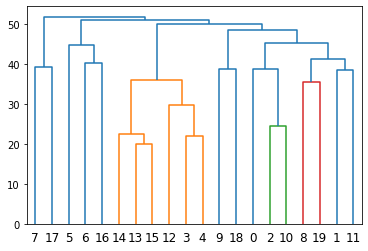

In [ ]:
# ====================
# =====   TODO   =====
# ====================
# your code here


**Conclusions:**
